# Load packages

In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
main_color = 'steelblue'
dark_color = 'navy'
accent_color = 'orange'

# Data loading

In [3]:
meteo_original_path = 'Data/meteo_pivoted_original.parquet'
df_meteo = pd.read_parquet(meteo_original_path)

In [4]:
df_meteo.dtypes

parameter
starttime      datetime64[ns]
CO2                   float64
Hr                    float64
Hr_Trockner           float64
NO                    float64
NO2                   float64
NOx                   float64
PM2.5                 float64
PN[5-100nm]           float64
RainDur               float64
SO2                   float64
StrGlo                float64
T                     float64
T_Trockner            float64
WD                    float64
WVv                   float64
eBC2.5                float64
dtype: object

In [5]:
df_meteo.set_index('starttime', inplace=True)

# Inital exploration and visualization

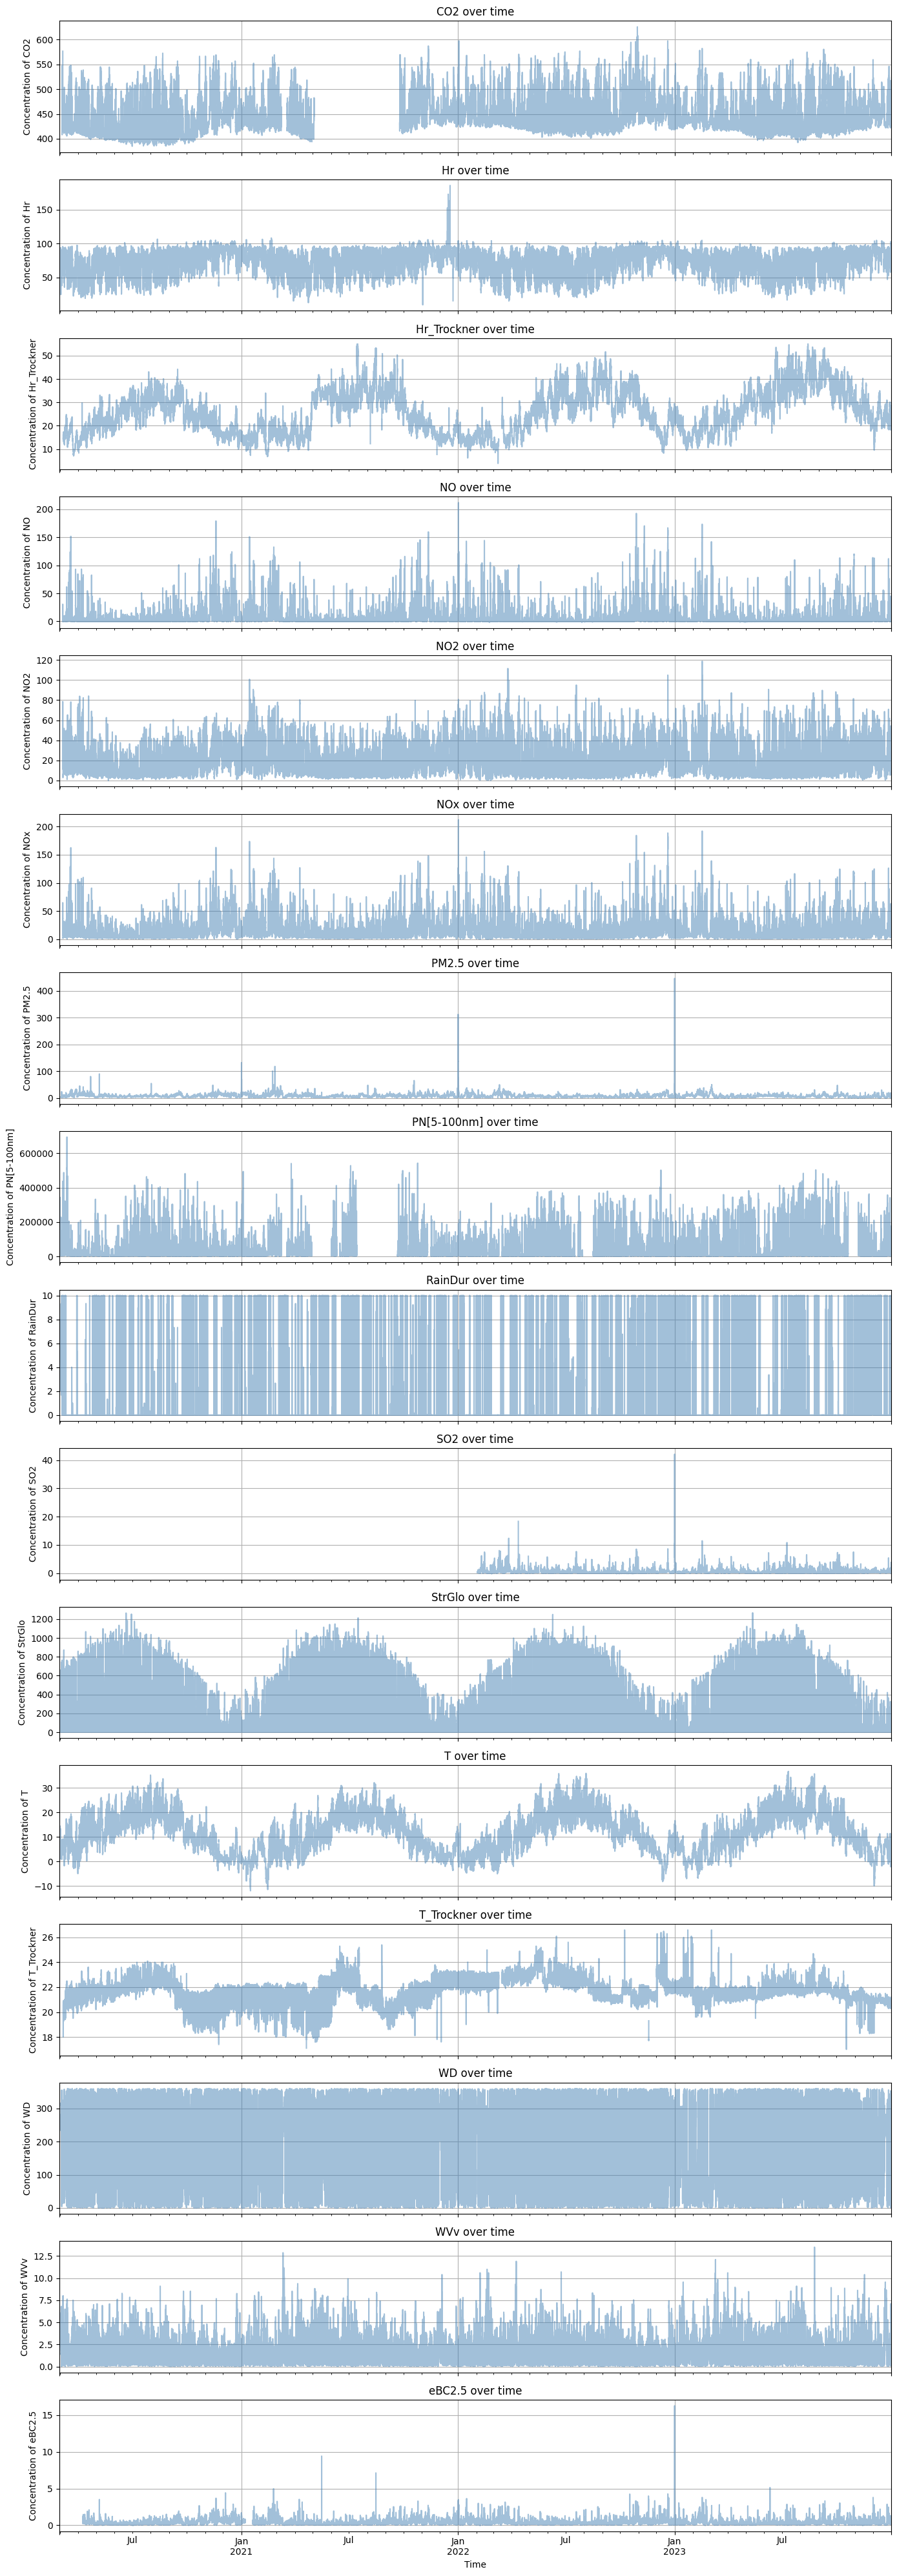

In [6]:

fig, axes = plt.subplots(nrows=len(df_meteo.columns), ncols=1, figsize=(14,40), sharex=True)

for i, col in enumerate(df_meteo.columns):
    # Original, non-smoothed data
    df_meteo[col].plot(ax=axes[i], alpha=0.5, label='Original data', color=main_color)
    # Smoothed line (1-hour rolling average)
    # df_meteo[col].rolling(window=18, center=True).median().plot(ax=axes[i], alpha=0.9, label='1-day rolling avg', color=accent_color)

    axes[i].set_title(f'{col} over time')
    axes[i].set_ylabel(f'Concentration of {col}')
    axes[i].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [7]:
display(df_meteo.columns)

display(df_meteo.describe())

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5'],
      dtype='object', name='parameter')

parameter,CO2,Hr,Hr_Trockner,NO,NO2,NOx,PM2.5,PN[5-100nm],RainDur,SO2,StrGlo,T,T_Trockner,WD,WVv,eBC2.5
count,178678.000000,200827.000000,197782.000000,197939.000000,197938.000000,197941.000000,201366.000000,166235.000000,201321.000000,97154.000000,201864.000000,200850.000000,197880.000000,200911.000000,200908.000000,193514.000000
mean,444.004087,73.452118,25.752014,4.191632,16.060905,11.759236,8.641604,20673.143189,0.985878,0.391995,152.772812,11.529548,21.716993,169.633715,1.670690,0.317308
std,32.908247,18.383858,9.224186,10.521734,12.123265,13.120174,5.971996,37102.182202,2.860465,0.605668,245.571509,8.033208,0.997741,108.344818,1.256712,0.287080
min,384.868065,9.700000,3.850000,-1.208949,-0.242115,-0.007394,1.257804,23.212007,0.000000,-0.201082,0.000000,-12.000000,17.000000,0.000000,0.000000,0.000000
25%,420.453994,60.800000,17.800000,0.238832,7.062721,4.099633,4.736670,4235.332573,0.000000,0.115998,2.000000,5.250000,21.100000,72.000000,0.782000,0.140419
50%,434.977682,78.000000,25.100000,0.790839,12.313287,7.287159,7.305140,9049.145837,0.000000,0.238283,7.000000,11.300000,21.700000,133.000000,1.290000,0.229504
75%,462.074038,88.900000,32.700000,2.684188,21.903428,14.133721,11.049600,19877.188036,0.000000,0.453648,206.000000,17.400000,22.400000,274.000000,2.220000,0.401632
max,625.707082,186.000000,55.000000,211.722136,118.783754,211.932395,445.734000,694578.042012,10.000000,42.135267,1267.000000,36.800000,26.600000,360.000000,13.500000,16.289764


Note: around 18.12.2021, there are several values of Hr (ambient air relative humidity in %) which greatly exceed 100% (going up to 186%), which points to probable problems with the sensor (fog condensing on sensor, calibraiton drift) (or software bugs, power issues when recording the data).

There are also several outliers (humidity level skipping by >50% within 10 minutes)

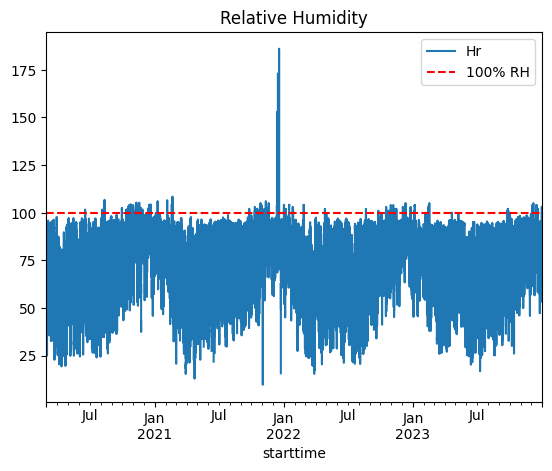

0.04% of Hr values are above 104%
0.55% of Hr values are above 100%


In [8]:
df_meteo['Hr'].plot(title='Relative Humidity')
plt.axhline(100, color='red', linestyle='--', label='100% RH')
plt.legend()
plt.show()

percentage_above_104 = (df_meteo['Hr'] > 104).mean() * 100
print(f"{percentage_above_104:.2f}% of Hr values are above 104%")

percentage_above_100 = (df_meteo['Hr'] > 100).mean() * 100
print(f"{percentage_above_100:.2f}% of Hr values are above 100%")


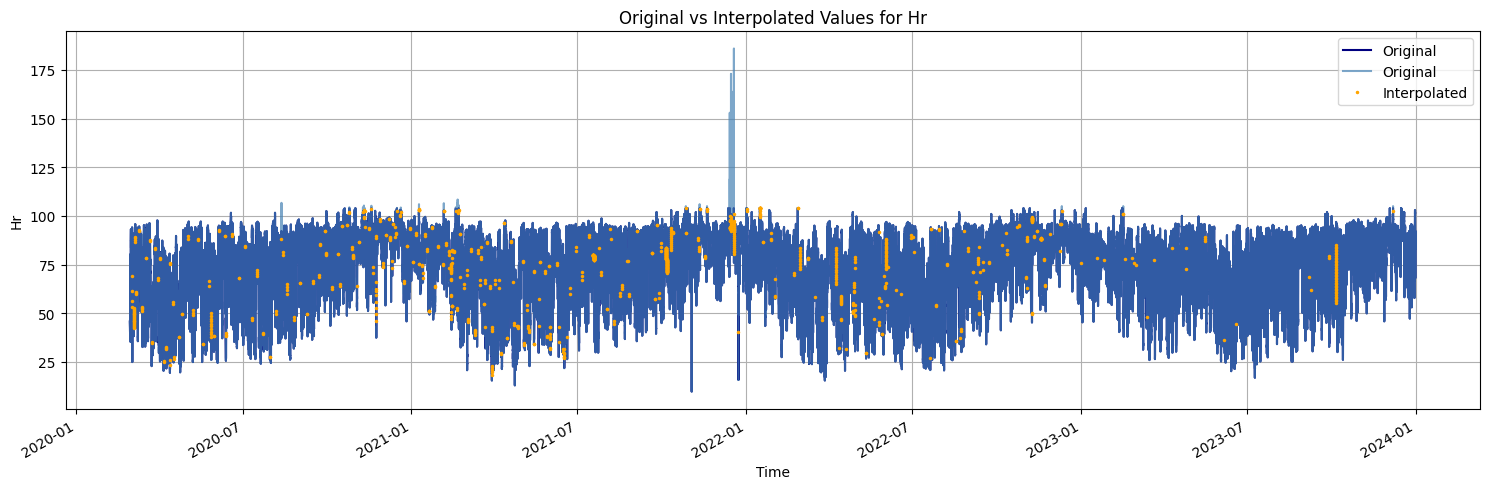

0.00% of Hr values are above 104%
0.54% of Hr values are above 100%


In [9]:
col = 'Hr'
original = df_meteo[col].copy()
invalid = original > 104
original.loc[invalid] = np.nan

filled = original.interpolate(method='linear', limit=144, limit_direction='both')

# Create mask where interpolation happened
interpolated_mask = original.isna() & filled.notna()

# Step 4: Plot
plt.figure(figsize=(15, 5))

# Original non-NaN values
filled[~interpolated_mask].plot(label='Original', color=dark_color)
df_meteo[col].plot(label='Original', color=main_color, alpha=0.7)

# Interpolated values
filled[interpolated_mask].plot(label='Interpolated', linestyle='none', marker='.', markersize=3, color=accent_color)

plt.title(f'Original vs Interpolated Values for {col}')
plt.xlabel('Time')
plt.ylabel(col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df_meteo[col] = filled

percentage_above_104 = (df_meteo[col] > 104).mean() * 100
print(f"{percentage_above_104:.2f}% of Hr values are above 104%")

percentage_above_100 = (df_meteo[col] > 100).mean() * 100
print(f"{percentage_above_100:.2f}% of Hr values are above 100%")

starttime
2020-03-04 07:00:00    38.2
2021-11-02 12:40:00     9.7
2021-12-23 12:30:00    15.7
Name: Hr, dtype: float64


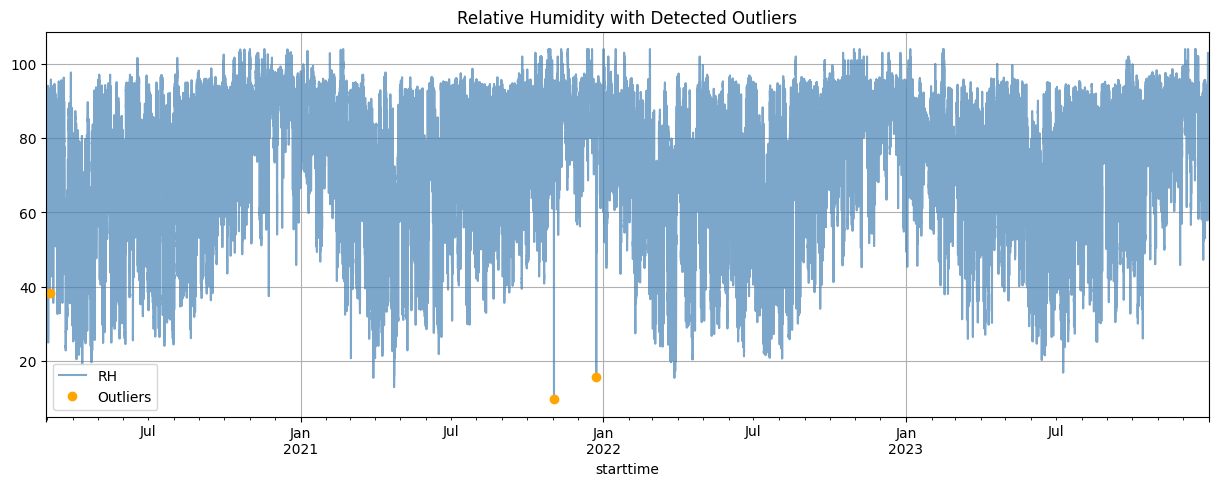

In [10]:
# Set a short window:
window = 5
threshold = 40  # percent deviation

# Rolling median - use this to test if certain values are deviating too much
rolling_median = df_meteo['Hr'].rolling(window=window, center=True).median()

# Absolute difference from median
deviation = (df_meteo['Hr'] - rolling_median).abs()

# Flag as outlier if deviation > threshold
outlier_mask = deviation > threshold

print(df_meteo.loc[outlier_mask, 'Hr'])

plt.figure(figsize=(15, 5))
df_meteo['Hr'].plot(label='RH', alpha=0.7, color=main_color)
df_meteo['Hr'][outlier_mask].plot(style='o', color=accent_color, label='Outliers')
plt.title('Relative Humidity with Detected Outliers')
plt.legend()
plt.grid(True)
plt.show()

Hr_cleaned = df_meteo['Hr'].copy()
Hr_cleaned[outlier_mask] = np.nan

Hr_interpolated = Hr_cleaned.interpolate(method='linear', limit_direction='both', limit=144)

df_meteo['Hr'] = Hr_interpolated



In [11]:
def detect_outliers(
        df: pd.DataFrame,
        col: str,
        window: int = 5,
        threshold: float = 3.0
        # threshold: float = 50.0
):
    df = df.copy()

    rolling_median = df[col].rolling(window=window, center=True).median()
    # Calculate absolute deviation from local rolling median
    deviation = (df[col] - rolling_median).abs()

    # relative_deviation = (df[col] - rolling_median).abs() / rolling_median
    # outlier_mask = relative_deviation > (threshold / 100)
    # rolling_mean = df[col].rolling(window=window, center=True).mean()
    # rolling_std = df[col].rolling(window=window, center=True).std()

    # Z-score based outlier detection
    # z_score = (df[col] - rolling_mean).abs() / rolling_std
    # outlier_mask = z_score > std_threshold

    # Outliers: large deviation from the local median
    outlier_mask = deviation > threshold

    print(df.loc[outlier_mask, col])
    if outlier_mask.any():  # only plot outliers if they exist
        plt.figure(figsize=(15, 5))
        df[col].plot(label=col, alpha=0.7, color=main_color)
        df_meteo[col][outlier_mask].plot(style='o', color=accent_color, label='Outliers')
        plt.title(col + ' with Detected Outliers')
        plt.legend()
        plt.grid(True)
        plt.show()
    


In [16]:
outlier_friendly_cols = ['Hr', 'Hr_Trockner', 'T', 'T_Trockner', 'WD', 'WVv', 'RainDur']

thresholds = {
    'Hr': 40,
    'Hr_Trockner': 40,
    'T': 10,
    'T_Trockner': 10,
    'WVv': 8,        
    'RainDur': 10     
}

for col, th in thresholds.items():
    detect_outliers(df_meteo, col=col, threshold=th)

Series([], Name: Hr, dtype: float64)
Series([], Name: Hr_Trockner, dtype: float64)
Series([], Name: T, dtype: float64)
Series([], Name: T_Trockner, dtype: float64)
Series([], Name: WVv, dtype: float64)
Series([], Name: RainDur, dtype: float64)


In [17]:
meteo_cleaned_path = 'Data/meteo_pivoted_cleaned.parquet'
df_meteo.to_parquet(meteo_cleaned_path)